# Tema : Modelos de suavización exponencial
![](src/img/logo_utb.png){width=40%} 
![](src/img/logo_etd.png){width=40%}
- **Profesor:**
- **Fernando Salcedo Mejía, Eco Msc.**
- Programa de Ciencias de Datos | Escuela de transformación digital.
- 2026-1

## Ejercicio 1. Pronostico del crecimiento PIB de Colombia.

<!-- - Usando los datos del Banco Mundial, estimar la Suavizamiento Exponencial Simple como función de prónostico del crecimento anual del PIB de Colombia. 1960-2024. Finalmente, realice el pronóstico del PIB de Colombia para los próximos 5 años. -->



In [16]:
# Librerias necesarias

# Datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wbgapi as wb

# Modelos de tiempo
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import SimpleExpSmoothing # Simple Exponential Smoothing
from statsmodels.tsa.holtwinters import Holt # Holt's Exponential Smoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing # Holt Winter's Exponential Smoothing
from statsmodels.tsa.exponential_smoothing.ets import ETSModel # ETS models.


import warnings
warnings.filterwarnings('ignore')


# Descargar los datos del Banco Mundial

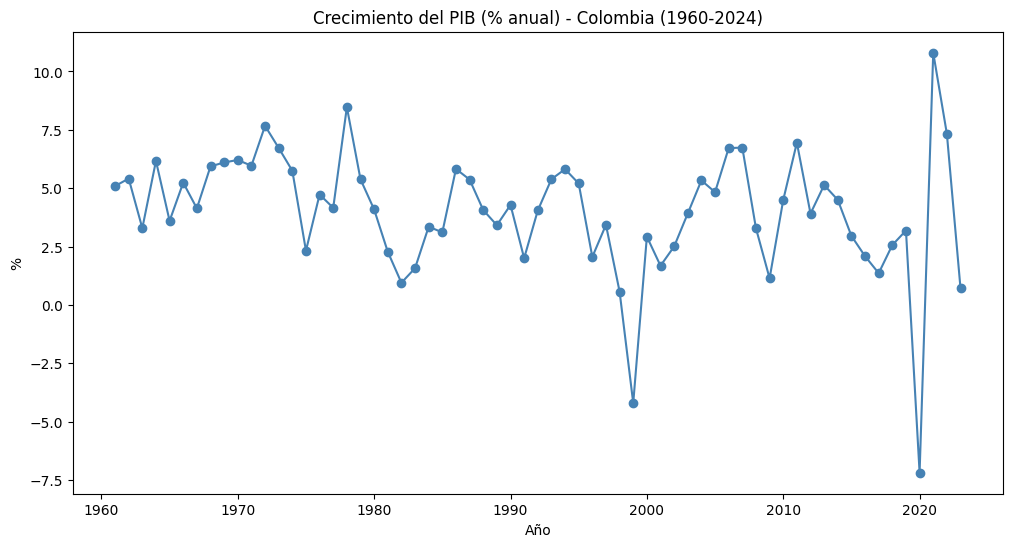

In [80]:
data = wb.data.DataFrame(series='NY.GDP.MKTP.KD.ZG', economy='COL', time=range(1960, 2024), columns='series').reset_index()
data.columns = ['year', 'pib']
data['year'] = data['year'].str.replace('YR', '').astype(int)
data = data.set_index('year')
pib_col = data['pib'].dropna()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(data.index, data['pib'], marker='o', color='steelblue')
ax.set_title('Crecimiento del PIB (% anual) - Colombia (1960-2024)')
ax.set_xlabel('Año')
ax.set_ylabel('%')
plt.show()


## Modelo SES

$$
\begin{align*}
\text{Ecuación de pronóstico} && \hat{y}_{t+h|t} = \ell_{t} \\
\text{Ecuación de suavizado} && \ell_{t} = \alpha y_{t} + (1 - \alpha)\ell_{t-1}
\end{align*}
$$

- Trend (None): El modelo asume que el PIB no tiene una tendencia alcista o bajista constante en el tiempo. Por eso, el pronóstico futuro será una línea recta horizontal.
- Seasonal (None): No se detectaron ni aplicaron patrones que se repitan (como ciclos anuales).

In [81]:
modelo_ses = SimpleExpSmoothing(pib_col, initialization_method="estimated").fit()
print(modelo_ses.summary())

                       SimpleExpSmoothing Model Results                       
Dep. Variable:                    pib   No. Observations:                   63
Model:             SimpleExpSmoothing   SSE                            451.337
Optimized:                       True   AIC                            128.052
Trend:                           None   BIC                            132.338
Seasonal:                        None   AICC                           128.742
Seasonal Periods:                None   Date:                 Thu, 09 Apr 2026
Box-Cox:                        False   Time:                         12:02:56
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.0517261                alpha                 True
initial_level              4.5991175                

$$
\begin{align*}
\text{Ecuación de pronóstico} && \hat{y}_{t+h|t} = \ell_{t} \\
\text{Ecuación de suavizado} && \ell_{t} = 0.0517261 y_{t} + (1 - 0.0517261)\ell_{t-1} \\
\text{Valor inicial} && \ell_{0} = 4.5991175
\end{align*}
$$

### Interpretación

- El modelo le asigna solo un 5.17% de peso al dato más reciente (el último año observado) y un 94.83% de peso a la historia previa (el nivel suavizado anterior).
- El valor $\alpha$ al ser un valor muy cercano a 0, el modelo es muy conservador e ignora las fluctuaciones de corto plazo y prefiere mantener un promedio estable de largo plazo ($\ell_{0}$).


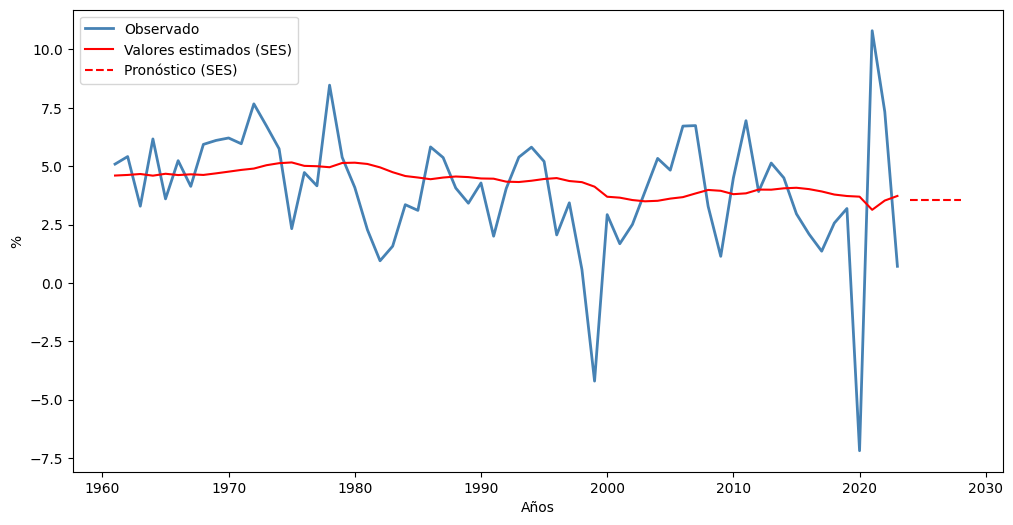

In [86]:
# Pronostico de los proximos 5 años
t_pronostico = 5
ultimo_dato  = pib_col.index[-1]
anio_pronostico = range(ultimo_dato + 1, ultimo_dato + 1 + t_pronostico)

# Obtener valores promedios e intervalos del pronostico
pronostico_ses = modelo_ses.forecast(steps=t_pronostico)
pronostico_ses.index = anio_pronostico

# Graficar resultados pronostico
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(pib_col.index, pib_col, label="Observado", color='steelblue', linewidth=2)
ax.plot(pib_col.index, modelo_ses.fittedvalues, label="Valores estimados (SES)", color='red')
ax.plot(pronostico_ses.index, pronostico_ses, label="Pronóstico (SES)", color='red', linestyle='--')
ax.set_xlabel('Años')
ax.set_ylabel('%')
ax.legend()
plt.show()

## Modelo Holt con tendencia constante y amortiguada

### Holt tendencia

$$
\begin{align*}
  \text{Ecuación de pronóstico}&& \hat{y}_{t+h|t} = \ell_{t} + hb_{t} \\
  \text{Ecuación nivel}   && \ell_{t} = \alpha y_{t} + (1 - \alpha)(\ell_{t-1} + b_{t-1})\\
  \text{Ecuación tendencia}   && b_{t}    = \beta^*(\ell_{t} - \ell_{t-1}) + (1 -\beta^*)b_{t-1}
\end{align*}
$$

### Holt tendencia amortiguada

$$
\begin{align*}
  \text{Ecuación de pronóstico}&& \hat{y}_{t+h|t} &= \ell_{t} + (\phi+\phi^2 + \dots + \phi^{h})b_{t} \\
  \text{Ecuación nivel}   && \ell_{t} &= \alpha y_{t} + (1 - \alpha)(\ell_{t-1} + \phi b_{t-1})\\
  \text{Ecuación tendencia}   && b_{t} &= \beta^*(\ell_{t} - \ell_{t-1}) + (1 -\beta^*)\phi b_{t-1}
\end{align*}
$$

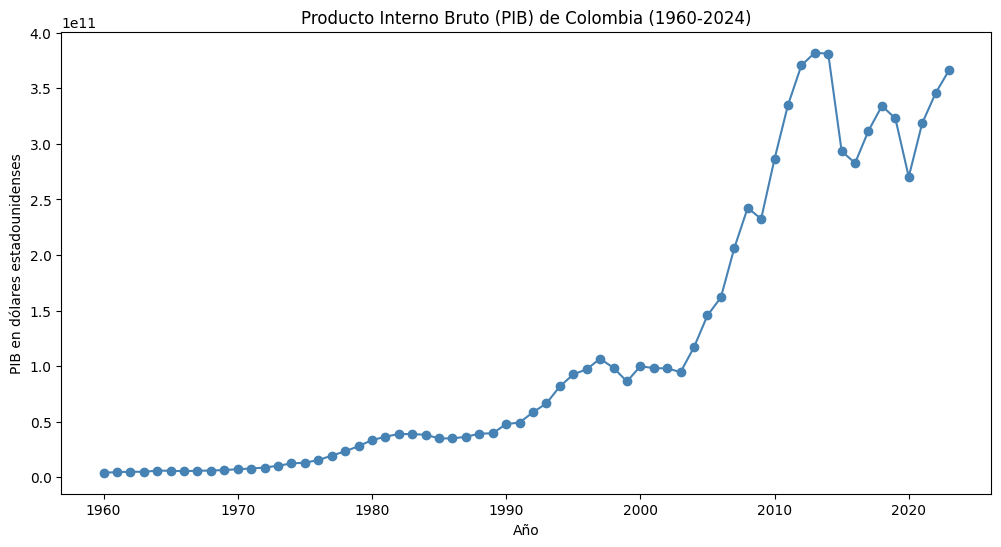

In [78]:
data = wb.data.DataFrame(series='NY.GDP.MKTP.CD', economy='COL', time=range(1960, 2024), columns='series').reset_index()
data.columns = ['year', 'pib']
data['year'] = data['year'].str.replace('YR', '').astype(int)
data = data.set_index('year')
data["pib"] = data["pib"]
pib_col = data['pib']

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(data.index, pib_col, marker='o', color='steelblue')
ax.set_title('Producto Interno Bruto (PIB) de Colombia (1960-2024)')
ax.set_xlabel('Año')
ax.set_ylabel('PIB en dólares estadounidenses')
plt.show()


In [74]:
# Modelo Holt
modelo_holt = Holt(pib_col, initialization_method="estimated").fit()
# Modelo Holt tendencia amortiguada
modelo_holt_damped_trend = Holt(pib_col, damped_trend = True, initialization_method="estimated").fit()


In [75]:
# Imprimir modelos
print("Modelo de Holt con tendencia\n")
print(modelo_holt.summary())

Modelo de Holt con tendencia

                                   Holt Model Results                                  
Dep. Variable:                    pib   No. Observations:                            64
Model:                           Holt   SSE                 26375440606726337855488.000
Optimized:                       True   AIC                                    3045.942
Trend:                       Additive   BIC                                    3054.577
Seasonal:                        None   AICC                                   3047.415
Seasonal Periods:                None   Date:                          Thu, 09 Apr 2026
Box-Cox:                        False   Time:                                  12:01:38
Box-Cox Coeff.:                  None                                                  
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level     

### Interpretación

$$
\begin{align*}
  \text{Ecuación de pronóstico}&& \hat{y}_{t+h|t} = \ell_{t} + hb_{t} \\
  \text{Ecuación nivel}   && \ell_{t} = 1.0000000 y_{t} + (1 - 1.0000000)(\ell_{t-1} + b_{t-1})\\
  \text{Ecuación tendencia}   && b_{t}    = 0^*(\ell_{t} - \ell_{t-1}) + (1 -0^*)b_{t-1} \\
  \text{Valor inicial} && \ell_{0} = 3.6556e+09 && b_{0} = 5.6533e+09
\end{align*}
$$

- Es modelo estima $\alpha$ con valor máximo posible indicando que le da un peso del 100% a la observación más reciente y olvida por completo el nivel calculado anteriormente. A su vez, $b = 0$ con el valor mínimo posible indica que modelo no actualiza la pendiente con los datos nuevos.
- De forma conjunta el modelo se comporta como una caminata aleatora. Solo depende del valor anterior y los valores iniciales tanto de la serie como de la tendencia se mantienen están presentes en todo momento.


In [76]:
# Imprimir modelos
print("Modelo de Holt con tendencia amortiguada\n")
print(modelo_holt_damped_trend.summary())

Modelo de Holt con tendencia amortiguada

                                   Holt Model Results                                  
Dep. Variable:                    pib   No. Observations:                            64
Model:                           Holt   SSE                 26987129298023429963776.000
Optimized:                       True   AIC                                    3049.409
Trend:                       Additive   BIC                                    3060.203
Seasonal:                        None   AICC                                   3051.409
Seasonal Periods:                None   Date:                          Thu, 09 Apr 2026
Box-Cox:                        False   Time:                                  12:01:45
Box-Cox Coeff.:                  None                                                  
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothin

### Interpretación

$$
\begin{align*}
  \text{Ecuación de pronóstico}&& \hat{y}_{t+h|t} &= \ell_{t} + (0.9950000 + 0.9950000^2 + \dots + 0.9950000^{h})b_{t} \\
  \text{Ecuación nivel}   && \ell_{t} &= 1.0000000 y_{t} + (1 - 1.0000000)(\ell_{t-1} + 0.9950000 b_{t-1})\\
  \text{Ecuación tendencia}   && b_{t} &= 0.0408419^*(\ell_{t} - \ell_{t-1}) + (1 -0.0408419^*)0.9950000 b_{t-1} \\
  \text{Valor inicial} && \ell_{0} = 4.0678e+09 && b_{0} = 1.0495e+09
\end{align*}
$$ 

- Similar a los resultados del modelo anterior. Sin embargo tenemos al nuevo parámetro $\phi = 0.9950000$ indicando que la tendencia se irá amortiguando o debilitando lentamente con el tiempo. Esto genera pronósticos más conservadores



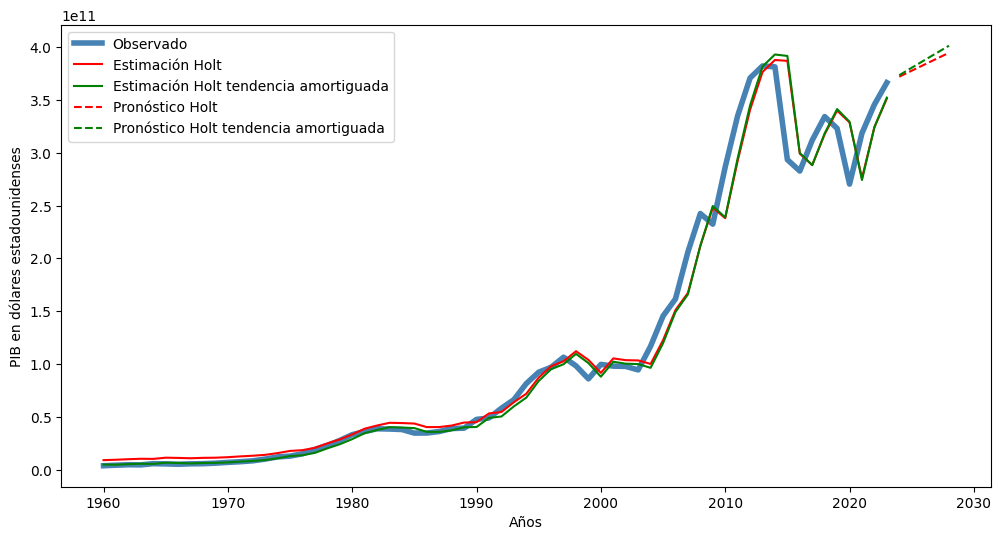

In [ ]:
# Pronostico de los proximos 5 años
t_pronostico = 5
ultimo_dato  = pib_col.index[-1]
anio_pronostico = range(ultimo_dato + 1, ultimo_dato + 1 + t_pronostico)

# Obtener valores promedios e intervalos del pronostico
pronostico_holt = modelo_holt.forecast(steps=t_pronostico)
pronostico_holt.index = anio_pronostico
pronostico_holt_damped_trend = modelo_holt_damped_trend.forecast(steps=t_pronostico)
pronostico_holt_damped_trend.index = anio_pronostico

# Graficar resultados pronostico
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(pib_col.index, pib_col, label="Observado", color='steelblue', linewidth=4)
ax.plot(pib_col.index, modelo_holt.fittedvalues, label="Estimación Holt", color='red')
ax.plot(pib_col.index, modelo_holt_damped_trend.fittedvalues, label="Estimación Holt tendencia amortiguada", color='green')

ax.plot(pronostico_holt.index, pronostico_holt, label="Pronóstico Holt", color='red', linestyle='--')
ax.plot(pronostico_holt_damped_trend.index, pronostico_holt_damped_trend, label="Pronóstico Holt tendencia amortiguada", color='green', linestyle='--')

ax.set_xlabel('Años')
ax.set_ylabel('PIB en dólares estadounidenses')
ax.legend()
plt.show()

## Holt-Winters estacionalidad
#### Método aditivo
$$
\begin{align*}
  \text{Ecuación de pronóstico}&& \hat{y}_{t+h|t} &= \ell_{t} + hb_{t} + s_{t+h-m(k+1)} \\
  \text{Ecuación nivel}&& \ell_{t} &= \alpha(y_{t} - s_{t-m}) + (1 - \alpha)(\ell_{t-1} + b_{t-1})\\
  \text{Ecuación tendencia}&& b_{t} &= \beta^*(\ell_{t} - \ell_{t-1}) + (1 - \beta^*)b_{t-1}\\
  \text{Ecuación estacional}&& s_{t} &= \gamma (y_{t}-\ell_{t-1}-b_{t-1}) + (1-\gamma)s_{t-m},
\end{align*}
$$

#### Método multiplicativo
$$
\begin{align*}
  \text{Ecuación de pronóstico}&& \hat{y}_{t+h|t} &= (\ell_{t} + hb_{t})s_{t+h-m(k+1)} \\
  \text{Ecuación nivel}&& \ell_{t} &= \alpha \frac{y_{t}}{s_{t-m}} + (1 - \alpha)(\ell_{t-1} + b_{t-1})\\
  \text{Ecuación tendencia}&& b_{t} &= \beta^*(\ell_{t}-\ell_{t-1}) + (1 - \beta^*)b_{t-1}                \\
  \text{Ecuación estacional}&& s_{t} &= \gamma \frac{y_{t}}{(\ell_{t-1} + b_{t-1})} + (1 - \gamma)s_{t-m}.
\end{align*}
$$


## Ejemplo 2. Desemplo en Colombia

- En este ejemplo, comparamos el desempeño predictivo de los tres métodos de suavizamiento exponencial que hemos considerado hasta ahora para pronosticar la tasa de desemplo en Colombia.